In [62]:
%%HTML
<style>
body {
    --vscode-font-family : 'Nasalization';
}

.dataframe {
    font-family : 'Futura';
    # font-family : 'Century Gothic';
    border : 2px solid #252422;
    border-radius : 5px;
    overflow : hidden;
}

.dataframe tr th {
    text-align : center;
}

.dataframe td {
    paddign : 10px;
    text-align : left;
}

.dataframe tr:hover{
    background-color : #ef233c;
}

</style>

# 🛳️ Importation

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, LabelEncoder, LabelBinarizer, MinMaxScaler, RobustScaler, StandardScaler
from sklearn.datasets import load_iris

# 🎯 Main

Il faut diviser le dataset en deux parties :
- Train
- Test

Les transformers s'appliquent uniquement sur les données train !

## 🎭 Encoding

### 📍 Label Encoder

LabelEncoder a été développé spécifiquement pour les les label Y

⚠️ Donc uniquement une seule colonne !

In [64]:
y = np.array(["chat", "chien", "chat", "oiseau"])
encoder = LabelEncoder()
encoder.fit(y)

LabelEncoder()

In [65]:
# Afficher les labels originaux
encoder.classes_

array(['chat', 'chien', 'oiseau'], dtype='<U6')

In [66]:
# Appliquer l'encodage
encoder.transform(y)

array([0, 1, 0, 2])

In [67]:
# Ou on peut combiner les deux étapes directement
encoder.fit_transform(y)

array([0, 1, 0, 2])

In [68]:
# Pour inverser la transformations
y_encoded = np.random.choice([0, 1, 2], size=50)
encoder.inverse_transform(y_encoded)

array(['chien', 'chat', 'chien', 'chat', 'oiseau', 'chien', 'chat',
       'chien', 'chien', 'chien', 'chien', 'oiseau', 'chat', 'chat',
       'chien', 'chat', 'oiseau', 'chat', 'chien', 'chien', 'oiseau',
       'oiseau', 'chat', 'chat', 'chat', 'oiseau', 'chat', 'oiseau',
       'chat', 'oiseau', 'oiseau', 'chat', 'chien', 'chien', 'chat',
       'chat', 'oiseau', 'chien', 'oiseau', 'chien', 'oiseau', 'chien',
       'chien', 'chat', 'chat', 'chien', 'oiseau', 'oiseau', 'chat',
       'oiseau'], dtype='<U6')

### 📍 Ordinal Encoding

`LabelEncoder` permet de transformer uniquement les tableaux de dim=1 <br>
Pour travailler sur plusieurs dim, il faut utiliser `OrdinalEncoder` <br>

In [69]:
data = np.array([
    ['avion', 'moto'],
    ['bateau', 'moto'],
    ['voiture', 'vélo'],
    ['avion', 'vélo'],
])

encoder = OrdinalEncoder()
encoder.fit_transform(data)

array([[0., 0.],
       [1., 0.],
       [2., 1.],
       [0., 1.]])

⚠️ Le fait de donner un numéro aux catégories peux induire le modèle en erreur car les numéro sont en ordre...

### 📍 One Hot Encoding

Fonctionnement sous forme de matrices, en binaire

In [70]:
data = [
    'avion',
    'bateau',
    'voiture',
    'moto',
    'vélo'
]

encoder = LabelBinarizer()
encoder.fit_transform(data)

array([[1, 0, 0, 0, 0],
       [0, 1, 0, 0, 0],
       [0, 0, 0, 1, 0],
       [0, 0, 1, 0, 0],
       [0, 0, 0, 0, 1]])

<Axes: >

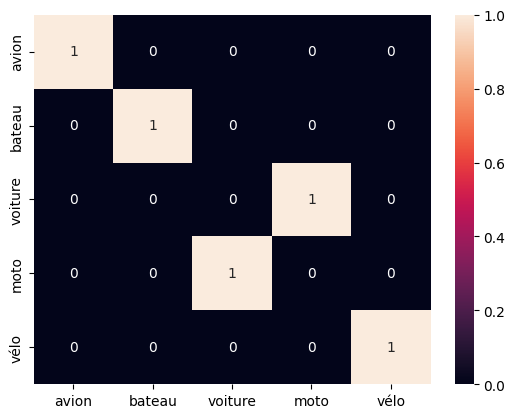

In [71]:
sns.heatmap(pd.DataFrame(encoder.fit_transform(data), index=data, columns=data), annot=True)

Sparse matrix = Matrice creuse

Une matrice qui représente une autre matrice

Un sparse matrix et utile quand il y a beaucoup de vides... cette nouvelle matrice enregristre les lignes et les colonnes de la grande matrice

⚠️ Le nombre de label n'évoluent pas avec le temps...

## 🎭 Normalisation

### 📍 MinMaxScaler

Chaque valeur de X sera comprise entre 0 et 1

$$
X_{scaled} = \frac{{X} - {X{min}}}{{X{max}} - {X{min}}}
$$

Les rapports d'écart seront conservées

⚠️ On `fit`uniquement sur les données train

$$
X_{test_{scaled}} = \frac{{X_{test}} - {X{train}_{min}}}{{X{train}_{max}} - {X{train}_{max}}}
$$

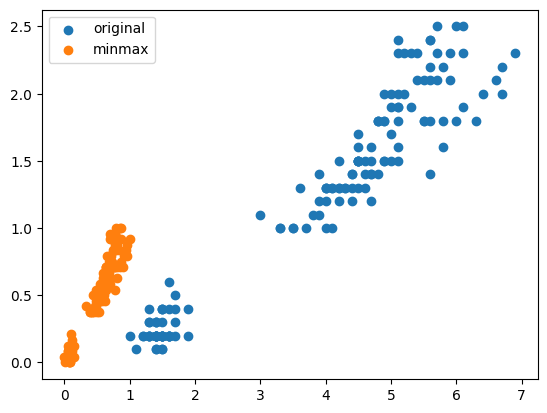

In [72]:
iris = load_iris()
X = iris.data

X_minmax = MinMaxScaler().fit_transform(X)

plt.scatter(X[:, 2], X[:, 3])
plt.scatter(X_minmax[:, 2], X_minmax[:, 3])
plt.legend(['original', 'minmax'])
plt.show()

### 📍 StandardScaler

Ici les données seront transformées de manière à avoir une moyenne = 0 et un écart-type = 1

$$
X_{scaled} = \frac{X - \mu{X}}{\sigma{X}}
$$

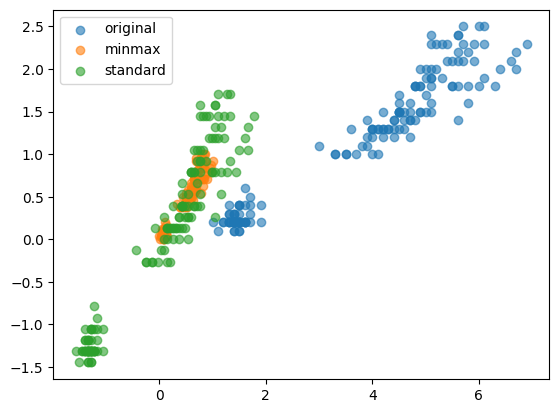

In [73]:
iris = load_iris()
X = iris.data

X_minmax = MinMaxScaler().fit_transform(X)
X_standard = StandardScaler().fit_transform(X)

plt.scatter(X[:, 2], X[:, 3], alpha=0.6)
plt.scatter(X_minmax[:, 2], X_minmax[:, 3], alpha=0.6)
plt.scatter(X_standard[:, 2], X_standard[:, 3], alpha=0.6)
plt.legend(['original', 'minmax', 'standard'])
plt.show()

### 📍 RobustScaler

Les deux méthodes précédentes sont très sensibles aux outliers...

Le robust scaler n'utilise pas la moyenne mais la médiane, et IQR au lieu de l'écart-type

$$
X_{scaled} = \frac{X - mediane}{IQR}
$$

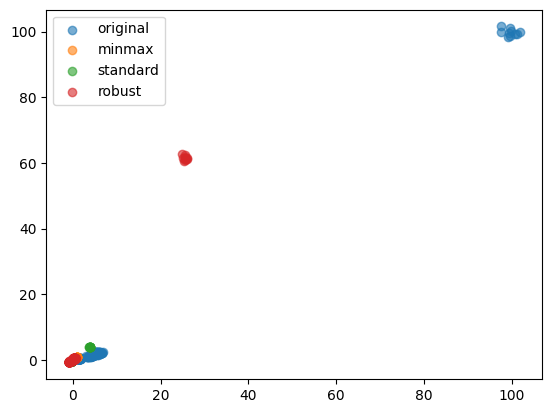

In [74]:
iris = load_iris()
X = iris.data

outliers = np.full((10, 4), 100) + np.random.randn(10, 4)
X = np.vstack((X, outliers))

X_minmax = MinMaxScaler().fit_transform(X)
X_standard = StandardScaler().fit_transform(X)
X_robust = RobustScaler().fit_transform(X)

plt.scatter(X[:, 2], X[:, 3], alpha=0.6)
plt.scatter(X_minmax[:, 2], X_minmax[:, 3], alpha=0.6)
plt.scatter(X_standard[:, 2], X_standard[:, 3], alpha=0.6)
plt.scatter(X_robust[:, 2], X_robust[:, 3], alpha=0.6)
plt.legend(['original', 'minmax', 'standard', 'robust'])
plt.show()